In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=f8e3551184c602b365a10ce9f54851cc804b57cc98f18303c03780e5d1f12c41
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lime
import lime.lime_tabular
import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from statsmodels.stats.contingency_tables import mcnemar

print("Environment ready.")

Environment ready.


In [4]:
FILE_PATH = "Thesis Dataset original(Diabetic,Non-Diabetic,Gastetional).xlsx"
TARGET_COLUMN_STATUS = "Diabetes_Status"

CLASS_MAP = {
    "non-diabetic": 0,
    "diabetic": 1,
    "gestational": 1
}

RANDOM_SEED = 42
print("Configuration Done.")

Configuration Done.


In [5]:
#--- Data Loading Function ---#
def load_data(file_path):
    try:
        df = pd.read_excel(file_path)
        df = df.dropna(subset=[TARGET_COLUMN_STATUS])
        df["Detection"] = df[TARGET_COLUMN_STATUS].astype(str).str.lower().map(CLASS_MAP)
        df = df.dropna(subset=["Detection"])
        df["Detection"] = df["Detection"].astype(int)
        print(f"Data loaded successfully. Rows: {len(df)}")
        return df
    except Exception as e:
        print(f"Error while loading data: {e}")
        return None

In [ ]:
df = load_data(FILE_PATH)
df.head()

Data loaded successfully. Rows: 2149


,Gender,Age,BSR mg/dl,Systolic,Diastolic,Perpheral_Neuropathy,BMI,Delayed_Healing,Genetic_Relation,Frequent_Urination,Dry Mouth,Frequent_Hunger,Diabetes_Status,Detection
0,1,53,297,147,94,1,22.0,1,0,1,0,1,Diabetic,1
1,1,55,265,167,90,0,26.0,0,1,0,1,0,Diabetic,1
2,1,73,100,108,113,0,27.4,0,0,0,0,0,Non-Diabetic,0
3,0,43,96,142,97,0,28.9,0,1,0,0,0,Non-Diabetic,0
4,0,39,406,148,94,1,22.0,0,0,1,1,0,Diabetic,1


In [ ]:
#--- Utility Functions ---#
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f"Confusion Matrix: {title}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

def plot_full_evaluation(y_true, y_pred, model_name):
    plot_cm(y_true, y_pred, model_name)
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred))
    print("=" * 60)

def run_lime_explanation(model, scaler, X_train_raw, user_input_df, feature_names, class_labels, title_suffix):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=scaler.transform(X_train_raw),
        feature_names=list(feature_names),
        class_names=class_labels,
        mode='classification'
    )

    exp = explainer.explain_instance(
        scaler.transform(user_input_df)[0],
        model.predict_proba,
        num_features=len(feature_names)
    )

    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Analysis: {title_suffix}\nModel: {model.__class__.__name__}")
    plt.tight_layout()
    plt.show()

print("Utility functions are ready")

Utility functions are ready


In [ ]:
#--- Stage 1 Data Preparation ---#
X_all = df.drop(columns=[TARGET_COLUMN_STATUS, "Detection"], errors="ignore")
y_all = df["Detection"]

X_train_det, X_test_det, y_train_det, y_test_det = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=RANDOM_SEED
)

scaler_det = StandardScaler()
X_train_det_s = scaler_det.fit_transform(X_train_det)
X_test_det_s = scaler_det.transform(X_test_det)

print("Stage 1 data prepared.")
print("Train shape:", X_train_det.shape)
print("Test shape:", X_test_det.shape)

Stage 1 data prepared.
Train shape: (1719, 12)
Test shape: (430, 12)


In [ ]:
#-- Stage 1 Models Along with Hyperparameters --#
models_stage1 = {
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        random_state=RANDOM_SEED
    ),
    "SVM": SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        gamma='scale',
        random_state=RANDOM_SEED
    ),
    "LogisticRegression": LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=None,
        criterion='gini',
        random_state=RANDOM_SEED
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        weights='uniform'
    )
}

optimized_det_results = {}
print("Stage 1 models are ready")

Stage 1 models are ready



RandomForest Training Complete. Accuracy: 1.0000
Avg. Prediction Confidence: 99.86%


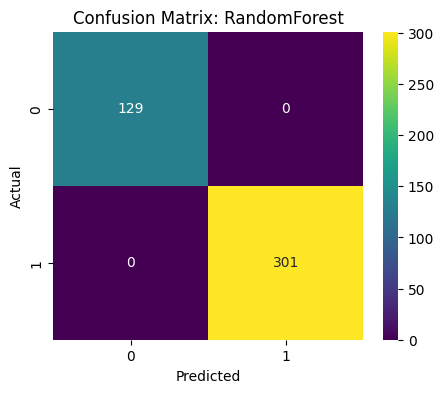


Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00       301

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430


SVM Training Complete. Accuracy: 1.0000
Avg. Prediction Confidence: 99.90%


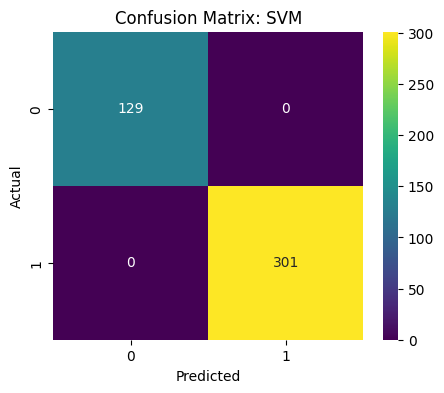


Classification Report for SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00       301

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430


LogisticRegression Training Complete. Accuracy: 1.0000
Avg. Prediction Confidence: 99.48%


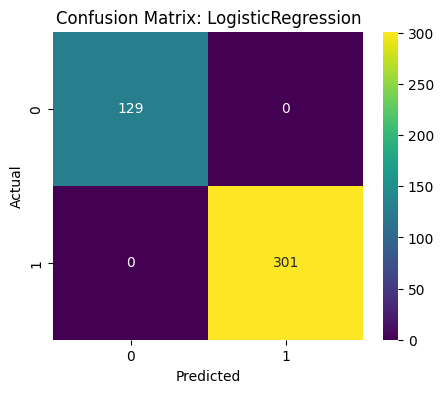


Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00       301

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430


DecisionTree Training Complete. Accuracy: 1.0000
Avg. Prediction Confidence: 100.00%


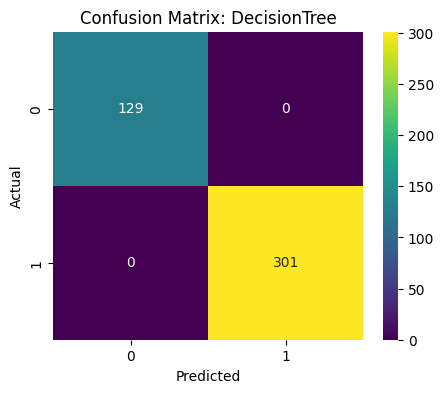


Classification Report for DecisionTree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00       301

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430


KNN Training Complete. Accuracy: 1.0000
Avg. Prediction Confidence: 99.84%


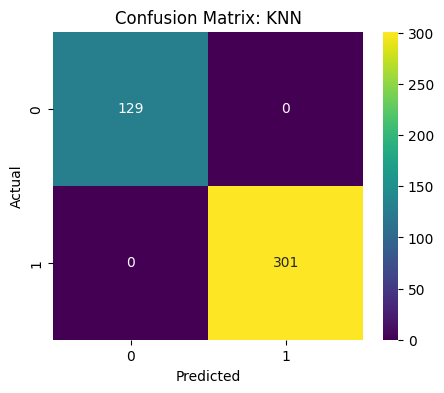


Classification Report for KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00       301

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430

Stage 1 Winner: RandomForest


In [ ]:
#-- Stage 1 Training --#
for name, model in models_stage1.items():
    model.fit(X_train_det_s, y_train_det)
    y_pred = model.predict(X_test_det_s)

    probs = model.predict_proba(X_test_det_s)
    avg_confidence = np.mean(np.max(probs, axis=1)) * 100
    acc = accuracy_score(y_test_det, y_pred)

    optimized_det_results[name] = {
        "model": model,
        "accuracy": acc
    }

    print(f"\n{name} Training Complete. Accuracy: {acc:.4f}")
    print(f"Avg. Prediction Confidence: {avg_confidence:.2f}%")

    plot_full_evaluation(y_test_det, y_pred, name)

best_det_name = max(optimized_det_results, key=lambda x: optimized_det_results[x]["accuracy"])
best_det_model = optimized_det_results[best_det_name]["model"]

print(f"Stage 1 Winner: {best_det_name}")

In [ ]:
#-- Stage 2 Data Preparation --#
df_cls = df[df[TARGET_COLUMN_STATUS].astype(str).str.lower().isin(["diabetic", "gestational"])].copy()

X_cls_all = df_cls.drop(columns=[TARGET_COLUMN_STATUS, "Detection"], errors="ignore")
y_cls_all = df_cls[TARGET_COLUMN_STATUS].astype(str).str.lower()

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_all,
    y_cls_all,
    test_size=0.2,
    stratify=y_cls_all,
    random_state=RANDOM_SEED
)

scaler_cls = StandardScaler()
X_train_cls_s = scaler_cls.fit_transform(X_train_cls)
X_test_cls_s = scaler_cls.transform(X_test_cls)

print("Stage 2 data prepared.")
print("Train shape:", X_train_cls.shape)
print("Test shape:", X_test_cls.shape)

Stage 2 data prepared.
Train shape: (1201, 12)
Test shape: (301, 12)


In [ ]:
#-- Stage 2 Models Along with Hyperparameters --#
models_stage2 = {
    "RF_CLS": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    "SVM_CLS": SVC(
        C=100,
        kernel='rbf',
        probability=True,
        random_state=RANDOM_SEED
    ),
    "LR_CLS": LogisticRegression(
        C=10,
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    ),
    "KNN_CLS": KNeighborsClassifier(
        n_neighbors=3,
        weights='distance'
    ),
    "DT_CLS": DecisionTreeClassifier(
        max_depth=None,
        criterion='gini',
        random_state=RANDOM_SEED
    )
}

optimized_cls_results = {}
print("Stage 2 models are ready")

Stage 2 models are ready



RF_CLS Training Complete.
Test Accuracy: 0.9900
Avg. Prediction Confidence: 97.75%


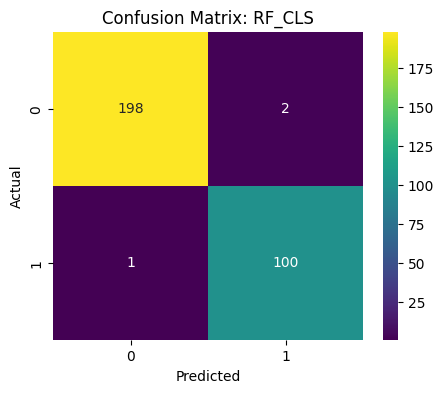


Classification Report for RF_CLS:
              precision    recall  f1-score   support

    diabetic       0.99      0.99      0.99       200
 gestational       0.98      0.99      0.99       101

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301


SVM_CLS Training Complete.
Test Accuracy: 0.9900
Avg. Prediction Confidence: 98.68%


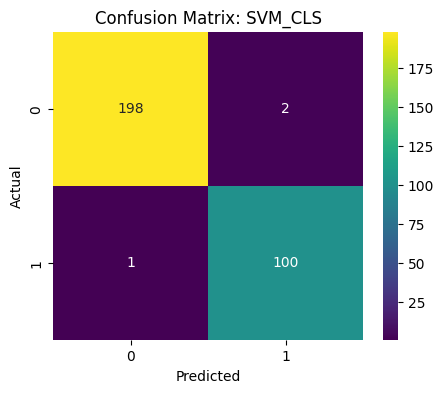


Classification Report for SVM_CLS:
              precision    recall  f1-score   support

    diabetic       0.99      0.99      0.99       200
 gestational       0.98      0.99      0.99       101

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301


LR_CLS Training Complete.
Test Accuracy: 0.9801
Avg. Prediction Confidence: 97.03%


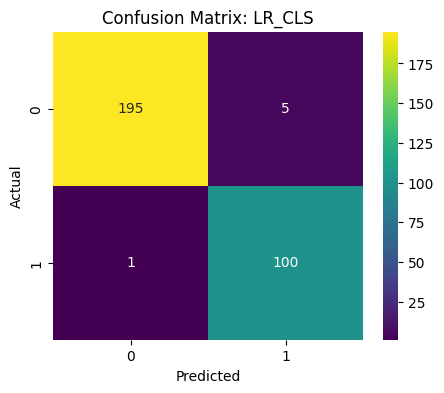


Classification Report for LR_CLS:
              precision    recall  f1-score   support

    diabetic       0.99      0.97      0.98       200
 gestational       0.95      0.99      0.97       101

    accuracy                           0.98       301
   macro avg       0.97      0.98      0.98       301
weighted avg       0.98      0.98      0.98       301


KNN_CLS Training Complete.
Test Accuracy: 0.9801
Avg. Prediction Confidence: 99.11%


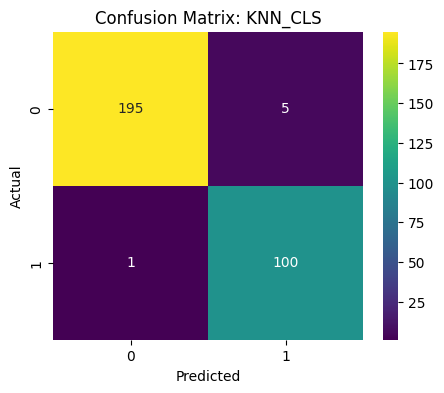


Classification Report for KNN_CLS:
              precision    recall  f1-score   support

    diabetic       0.99      0.97      0.98       200
 gestational       0.95      0.99      0.97       101

    accuracy                           0.98       301
   macro avg       0.97      0.98      0.98       301
weighted avg       0.98      0.98      0.98       301


DT_CLS Training Complete.
Test Accuracy: 0.9834
Avg. Prediction Confidence: 100.00%


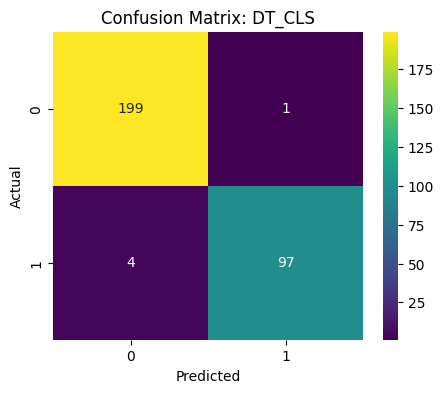


Classification Report for DT_CLS:
              precision    recall  f1-score   support

    diabetic       0.98      0.99      0.99       200
 gestational       0.99      0.96      0.97       101

    accuracy                           0.98       301
   macro avg       0.99      0.98      0.98       301
weighted avg       0.98      0.98      0.98       301

Stage 2 Winner: RF_CLS


In [ ]:
#-- Stage 2 Training --#
for name, model in models_stage2.items():
    model.fit(X_train_cls_s, y_train_cls)
    y_pred = model.predict(X_test_cls_s)

    probs = model.predict_proba(X_test_cls_s)
    avg_confidence = np.mean(np.max(probs, axis=1)) * 100
    acc = accuracy_score(y_test_cls, y_pred)

    optimized_cls_results[name] = {
        "model": model,
        "accuracy": acc
    }

    print(f"\n{name} Training Complete.")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Avg. Prediction Confidence: {avg_confidence:.2f}%")

    plot_full_evaluation(y_test_cls, y_pred, name)

best_cls_name = max(optimized_cls_results, key=lambda x: optimized_cls_results[x]["accuracy"])
best_cls_model = optimized_cls_results[best_cls_name]["model"]

print(f"Stage 2 Winner: {best_cls_name}")

In [ ]:
#-- Feature Statistical Analysis --#
def run_feature_analysis(df, target_col="Detection"):
    print("\n" + "=" * 25 + " FEATURE STATISTICAL ANALYSIS " + "=" * 25)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col_to_remove in [target_col, "Detection"]:
        if col_to_remove in numeric_cols:
            numeric_cols.remove(col_to_remove)

    stats_data = []
    g0 = df[df[target_col] == 0]
    g1 = df[df[target_col] == 1]

    for col in numeric_cols:
        t_stat, p_val = stats.ttest_ind(g0[col].dropna(), g1[col].dropna())
        corr = df[col].corr(df[target_col])

        stats_data.append({
            "Feature": col,
            "Correlation": f"{corr:.4f}",
            "P-Value": "{:.4e}".format(p_val),
            "Status": "Significant" if p_val < 0.05 else "Not Significant"
        })

    print(pd.DataFrame(stats_data).to_string(index=False))

run_feature_analysis(df)


========================= FEATURE STATISTICAL ANALYSIS =========================
             Feature Correlation     P-Value          Status
              Gender     -0.2138  1.2330e-23     Significant
                 Age     -0.1765  1.7144e-16     Significant
           BSR mg/dl      0.8642  0.0000e+00     Significant
            Systolic     -0.1006  2.9437e-06     Significant
           Diastolic     -0.0756  4.4940e-04     Significant
Perpheral_Neuropathy      0.4099  7.3717e-88     Significant
                 BMI      0.3675  1.0664e-69     Significant
     Delayed_Healing      0.4198  1.6359e-92     Significant
    Genetic_Relation      0.0008  9.7087e-01 Not Significant
  Frequent_Urination      0.5630 5.6129e-180     Significant
           Dry Mouth      0.5646 3.2099e-181     Significant
     Frequent_Hunger      0.5534 1.0337e-172     Significant


In [ ]:
#-- Stability Matrix --#
def run_stability_metrics(models_dict, X, y, stage_name):
    print("\n" + "=" * 20 + f" {stage_name}: METRICS (MEAN ± STD) " + "=" * 20)

    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
    summary = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    for name, model in models_dict.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

        summary.append({
            "Model Name": name,
            "Accuracy": f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
            "Precision": f"{cv_results['test_precision_weighted'].mean():.4f} ± {cv_results['test_precision_weighted'].std():.4f}",
            "Recall": f"{cv_results['test_recall_weighted'].mean():.4f} ± {cv_results['test_recall_weighted'].std():.4f}",
            "F1-Score": f"{cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}"
        })

    df_result = pd.DataFrame(summary)
    print(df_result.to_string(index=False))
    return df_result

In [ ]:
s1_stability = run_stability_metrics(models_stage1, X_train_det, y_train_det, "STAGE 1 DETECTION")
s2_stability = run_stability_metrics(models_stage2, X_train_cls, y_train_cls, "STAGE 2 CLASSIFICATION")


==================== STAGE 1 DETECTION: METRICS (MEAN ± STD) ====================
        Model Name        Accuracy       Precision          Recall        F1-Score
      RandomForest 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000
               SVM 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000
LogisticRegression 0.9988 ± 0.0023 0.9989 ± 0.0023 0.9988 ± 0.0023 0.9988 ± 0.0023
      DecisionTree 0.9983 ± 0.0023 0.9983 ± 0.0023 0.9983 ± 0.0023 0.9983 ± 0.0023
               KNN 0.9942 ± 0.0055 0.9943 ± 0.0054 0.9942 ± 0.0055 0.9942 ± 0.0055

==================== STAGE 2 CLASSIFICATION: METRICS (MEAN ± STD) ====================
Model Name        Accuracy       Precision          Recall        F1-Score
    RF_CLS 0.9867 ± 0.0067 0.9872 ± 0.0061 0.9867 ± 0.0067 0.9867 ± 0.0066
   SVM_CLS 0.9875 ± 0.0052 0.9879 ± 0.0050 0.9875 ± 0.0052 0.9876 ± 0.0052
    LR_CLS 0.9692 ± 0.0141 0.9712 ± 0.0126 0.9692 ± 0.0141 0.9695 ± 0.0139
   KNN_CLS 0.9717 ± 0.0089 0.97

In [ ]:
#-- MCNAMER TEST --#
def run_mcnemar_table(y_true, results_dict, best_name, X_test):
    print("\n" + "=" * 20 + f" McNEMAR TEST (vs {best_name}) " + "=" * 20)

    best_preds = results_dict[best_name]['model'].predict(X_test)
    mcn_list = []

    for name, data in results_dict.items():
        if name == best_name:
            continue

        other_preds = data['model'].predict(X_test)

        both_correct = np.sum((best_preds == y_true) & (other_preds == y_true))
        b = np.sum((best_preds == y_true) & (other_preds != y_true))
        c = np.sum((best_preds != y_true) & (other_preds == y_true))
        both_wrong = np.sum((best_preds != y_true) & (other_preds != y_true))

        if (b + c) == 0:
            mcn_list.append({
                "Model_A": best_name,
                "Model_B": name,
                "b": b,
                "c": c,
                "Statistic": "N/A",
                "P-Value": "Identical predictions"
            })
            continue

        table = [
            [both_correct, b],
            [c, both_wrong]
        ]

        if (b + c) < 25:
            res = mcnemar(table, exact=True)
        else:
            res = mcnemar(table, exact=False, correction=True)

        mcn_list.append({
            "Model_A": best_name,
            "Model_B": name,
            "b": b,
            "c": c,
            "Statistic": res.statistic,
            "P-Value": res.pvalue
        })

    print(pd.DataFrame(mcn_list).to_string(index=False))

In [ ]:
run_mcnemar_table(y_test_det, optimized_det_results, best_det_name, X_test_det_s)
run_mcnemar_table(y_test_cls, optimized_cls_results, best_cls_name, X_test_cls_s)


==================== McNEMAR TEST (vs RandomForest) ====================
     Model_A            Model_B  b  c Statistic               P-Value
RandomForest                SVM  0  0       N/A Identical predictions
RandomForest LogisticRegression  0  0       N/A Identical predictions
RandomForest       DecisionTree  0  0       N/A Identical predictions
RandomForest                KNN  0  0       N/A Identical predictions

==================== McNEMAR TEST (vs RF_CLS) ====================
Model_A Model_B  b  c  Statistic  P-Value
 RF_CLS SVM_CLS  1  1        1.0    1.000
 RF_CLS  LR_CLS  4  1        1.0    0.375
 RF_CLS KNN_CLS  4  1        1.0    0.375
 RF_CLS  DT_CLS  3  1        1.0    0.625


In [ ]:
#-- Random Seed Values --#
def run_seed_iteration_analysis(df_input, models_dict, feature_cols, target_col, stage_name):
    print(f"\n" + "=" * 30 + f" {stage_name}: SEED-WISE ANALYSIS " + "=" * 30)

    seeds = [0, 42, 70, 300]
    final_report = []

    for model_name, model_obj in models_dict.items():
        seed_results = []

        for seed in seeds:
            X = df_input[feature_cols]
            y = df_input[target_col]

            X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                test_size=0.2,
                random_state=seed,
                stratify=y
            )

            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)

            if hasattr(model_obj, 'random_state'):
                model_obj.random_state = seed

            model_obj.fit(X_train_s, y_train)
            y_pred = model_obj.predict(X_test_s)

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted')
            rec = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')

            seed_results.append([seed, acc, prec, rec, f1])

            final_report.append({
                "Model Name": model_name,
                "Seed": seed,
                "Accuracy": round(acc, 4),
                "Precision": round(prec, 4),
                "Recall": round(rec, 4),
                "F1 Score": round(f1, 4),
                "Type": "Individual"
            })

        res_np = np.array(seed_results)
        means = np.mean(res_np[:, 1:], axis=0)
        stds = np.std(res_np[:, 1:], axis=0)

        final_report.append({
            "Model Name": model_name,
            "Seed": "MEAN",
            "Accuracy": round(means[0], 4),
            "Precision": round(means[1], 4),
            "Recall": round(means[2], 4),
            "F1 Score": round(means[3], 4),
            "Type": "Stat"
        })

        final_report.append({
            "Model Name": model_name,
            "Seed": "STD DEV",
            "Accuracy": round(stds[0], 4),
            "Precision": round(stds[1], 4),
            "Recall": round(stds[2], 4),
            "F1 Score": round(stds[3], 4),
            "Type": "Stat"
        })

    report_df = pd.DataFrame(final_report)
    print(report_df.to_string(index=False))
    return report_df

In [ ]:
s1_features = [col for col in df.columns if col not in ["Detection", "Diabetes_Status"]]
s1_results = run_seed_iteration_analysis(df, models_stage1, s1_features, "Detection", "STAGE 1")

df_diabetic = df[df[TARGET_COLUMN_STATUS].astype(str).str.lower().isin(["diabetic", "gestational"])].copy()
s2_features = [col for col in df_diabetic.columns if col not in ["Detection", "Diabetes_Status"]]
s2_results = run_seed_iteration_analysis(df_diabetic, models_stage2, s2_features, "Diabetes_Status", "STAGE 2")


============================== STAGE 1: SEED-WISE ANALYSIS ==============================
        Model Name    Seed  Accuracy  Precision  Recall  F1 Score       Type
      RandomForest       0    1.0000     1.0000  1.0000    1.0000 Individual
      RandomForest      42    1.0000     1.0000  1.0000    1.0000 Individual
      RandomForest      70    1.0000     1.0000  1.0000    1.0000 Individual
      RandomForest     300    1.0000     1.0000  1.0000    1.0000 Individual
      RandomForest    MEAN    1.0000     1.0000  1.0000    1.0000       Stat
      RandomForest STD DEV    0.0000     0.0000  0.0000    0.0000       Stat
               SVM       0    1.0000     1.0000  1.0000    1.0000 Individual
               SVM      42    1.0000     1.0000  1.0000    1.0000 Individual
               SVM      70    1.0000     1.0000  1.0000    1.0000 Individual
               SVM     300    1.0000     1.0000  1.0000    1.0000 Individual
               SVM    MEAN    1.0000     1.0000  1.0000    1.0

In [ ]:
#-- Final Prediction pipeline --#
def final_prediction_pipeline(
    det_model, scaler_det,
    cls_model, scaler_cls,
    feature_cols,
    X_train_det_raw,
    X_train_cls_raw
):
    print("\n" + "=" * 55)
    print("PATIENT DIAGNOSIS & EXPLANATION SYSTEM")
    print("=" * 55)

    vals = []
    for col in feature_cols:
        while True:
            try:
                val = float(input(f"Enter {col}: "))
                vals.append(val)
                break
            except ValueError:
                print("Invalid input. Please enter numbers only.")

    input_df = pd.DataFrame([vals], columns=feature_cols)

    input_scaled_det = scaler_det.transform(input_df)

    pred_det = det_model.predict(input_scaled_det)[0]
    probs_det = det_model.predict_proba(input_scaled_det)[0]
    confidence_det = np.max(probs_det) * 100

    run_lime_explanation(
        model=det_model,
        scaler=scaler_det,
        X_train_raw=X_train_det_raw,
        user_input_df=input_df,
        feature_names=feature_cols,
        class_labels=['Non-Diabetic', 'Diabetic'],
        title_suffix="Detection Stage"
    )

    if pred_det == 0:
        print("\n" + "-" * 35)
        print("FINAL RESULT: Patient is NON-DIABETIC")
        print(f"Confidence: {confidence_det:.2f}%")
        print("-" * 35)
        return

    print(f"\nSTAGE 1 RESULT: Diabetes Detected (Confidence: {confidence_det:.2f}%)")
    print("Analyzing diabetes type...")

    input_scaled_cls = scaler_cls.transform(input_df)

    pred_type = cls_model.predict(input_scaled_cls)[0]
    probs_cls = cls_model.predict_proba(input_scaled_cls)[0]
    confidence_cls = np.max(probs_cls) * 100

    run_lime_explanation(
        model=cls_model,
        scaler=scaler_cls,
        X_train_raw=X_train_cls_raw,
        user_input_df=input_df,
        feature_names=feature_cols,
        class_labels=['Diabetic', 'Gestational'],
        title_suffix="Classification Stage"
    )

    print("\n" + "-" * 40)
    print("FINAL DIAGNOSIS: DIABETES DETECTED")
    print(f"Type: {pred_type}")
    print(f"Classification Confidence: {confidence_cls:.2f}%")
    print("-" * 40)


PATIENT DIAGNOSIS & EXPLANATION SYSTEM
Enter Gender: 1
Enter Age: 41
Enter BSR mg/dl: 168
Enter Systolic: 130
Enter Diastolic: 84
Enter Perpheral_Neuropathy: 0
Enter BMI: 24.5
Enter Delayed_Healing: 0
Enter Genetic_Relation: 0
Enter Frequent_Urination: 0
Enter Dry Mouth: 0
Enter Frequent_Hunger: 0


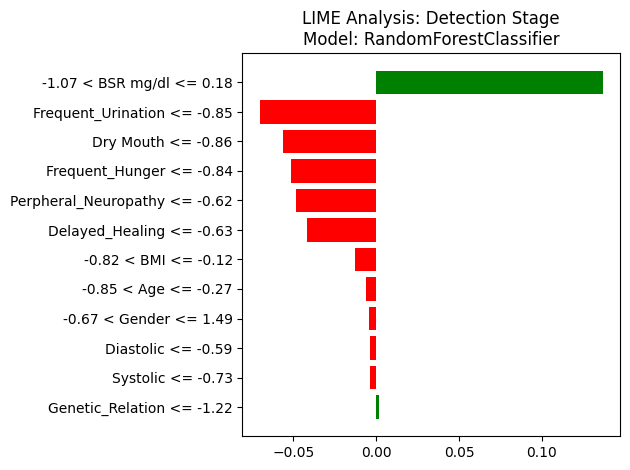


STAGE 1 RESULT: Diabetes Detected (Confidence: 66.00%)
Analyzing diabetes type...


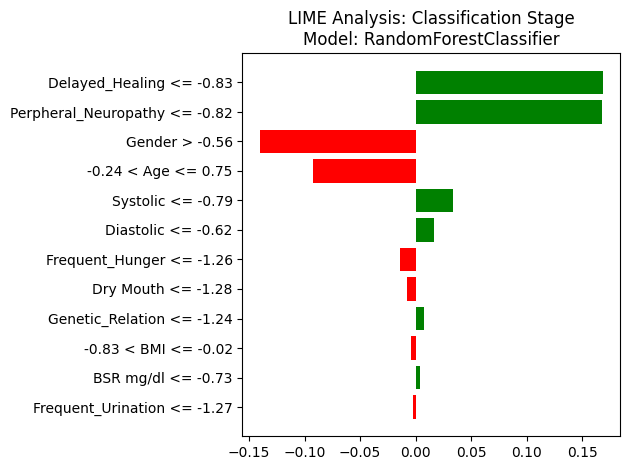


----------------------------------------
FINAL DIAGNOSIS: DIABETES DETECTED
Type: Diabetic
Classification Confidence: 94.00%
----------------------------------------


In [ ]:
final_prediction_pipeline(
    det_model=best_det_model,
    scaler_det=scaler_det,
    cls_model=best_cls_model,
    scaler_cls=scaler_cls,
    feature_cols=X_all.columns,
    X_train_det_raw=X_train_det,
    X_train_cls_raw=X_train_cls
)

In [ ]:
import pandas as pd

importances = best_det_model.feature_importances_
features = X_all.columns

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(df_imp)

                 Feature  Importance
2              BSR mg/dl    0.593277
9     Frequent_Urination    0.090679
10             Dry Mouth    0.081534
11       Frequent_Hunger    0.069285
6                    BMI    0.059479
5   Perpheral_Neuropathy    0.040783
7        Delayed_Healing    0.037688
0                 Gender    0.009545
1                    Age    0.009137
4              Diastolic    0.004545
3               Systolic    0.003990
8       Genetic_Relation    0.000057


In [ ]:
#-- Models Saving --#
joblib.dump(best_det_model, 'det_model.pkl')
joblib.dump(scaler_det, 'scaler_det.pkl')

joblib.dump(best_cls_model, 'cls_model.pkl')
joblib.dump(scaler_cls, 'scaler_cls.pkl')

joblib.dump(X_all.columns, 'feature_names.pkl')
joblib.dump(X_train_det_s[:500], 'training_sample.pkl')

print("Files successfully generated")

Files successfully generated!


In [ ]:
#-- Download Files --#
from google.colab import files

download_files = [
    'det_model.pkl',
    'scaler_det.pkl',
    'cls_model.pkl',
    'scaler_cls.pkl',
    'feature_names.pkl',
    'training_sample.pkl'
]

for file_name in download_files:
    files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>